<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 163.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 132.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 144.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 153.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 158.6 MB/s eta 0:00:00


#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




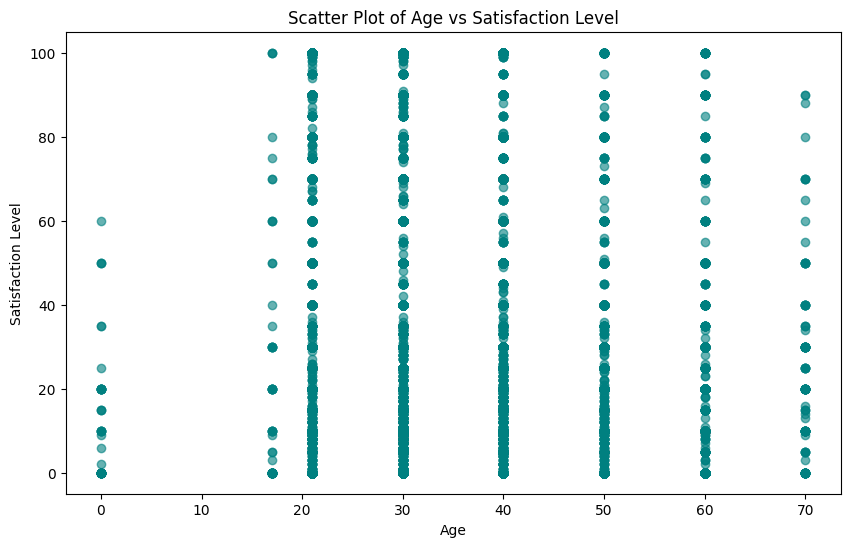

In [5]:
## Write your code here
df.head()
df.shape[0]

# Map Age to numeric (example: if Age is categorical like '25-34', '35-44', etc.)
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    'Prefer not to say': 0
}
df['AgeNumeric'] = df['Age'].map(age_map)

df= df.dropna(subset=["AgeNumeric","JobSatPoints_6"])

# Plot scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['AgeNumeric'], df['JobSatPoints_6'], alpha=0.6, color='teal')
plt.title('Scatter Plot of Age vs Satisfaction Level')
plt.xlabel('Age')
plt.ylabel('Satisfaction Level')
plt.grid(False)
plt.show()


#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


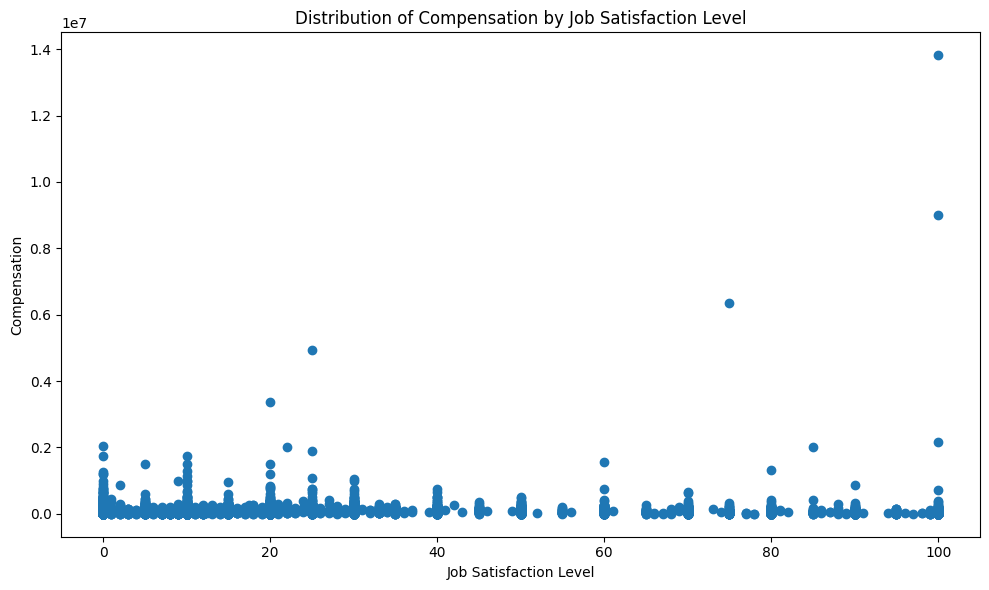

In [9]:
## Write your code here
#Drop NaN values
df = df.dropna(subset=['JobSatPoints_6', 'ConvertedCompYearly'])

# Filter out extreme outliers (e.g., above 90th percentile)
#upper_limit = df['CompTotal'].quantile(0.90)
#df_filtered = df[df['CompTotal'] <= upper_limit]


# Plot
plt.figure(figsize=(10, 6))
plt.scatter(x='JobSatPoints_6', y='ConvertedCompYearly', data=df)
plt.title('Distribution of Compensation by Job Satisfaction Level')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Compensation')
plt.tight_layout()
plt.show()

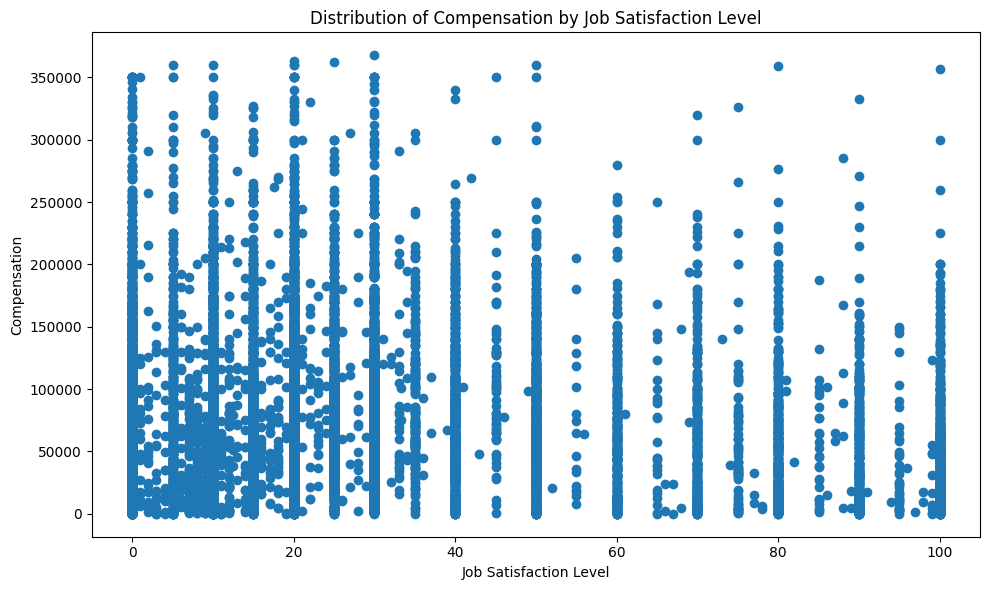

In [13]:
## Write your code here
#Drop NaN values
df = df.dropna(subset=['JobSatPoints_6', 'ConvertedCompYearly'])

# Filter out extreme outliers (e.g., above 90th percentile)
upper_limit = df['ConvertedCompYearly'].quantile(0.99)
df_filtered = df[df['ConvertedCompYearly'] <= upper_limit]


# Plot
plt.figure(figsize=(10, 6))
plt.scatter(x='JobSatPoints_6', y='ConvertedCompYearly', data=df_filtered)
plt.title('Distribution of Compensation by Job Satisfaction Level')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Compensation')
plt.tight_layout()
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


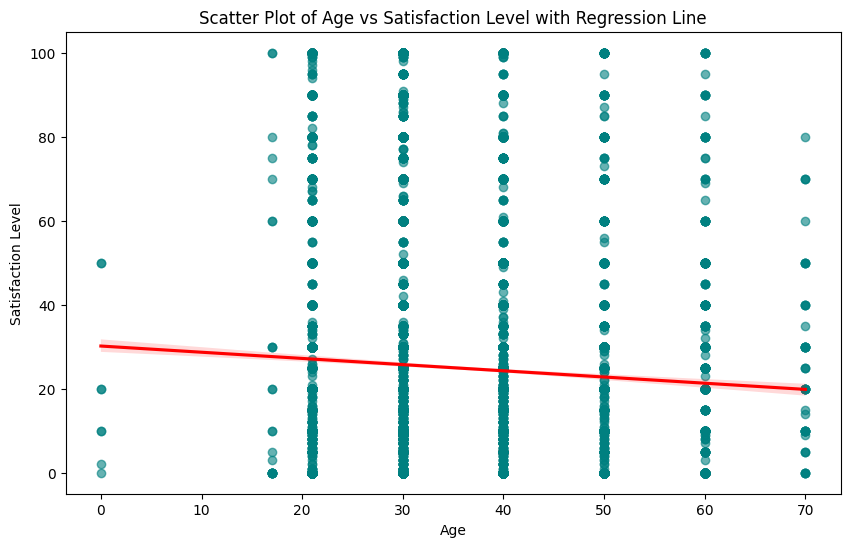

In [15]:
## Write your code here
!pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Plot scatter plot with regression line
plt.figure(figsize=(10, 6))
sns.regplot(
    x='AgeNumeric',
    y='JobSatPoints_6',
    data=df,
    scatter_kws={'alpha': 0.6, 'color': 'teal'},
    line_kws={'color': 'red'}
)
plt.title('Scatter Plot of Age vs Satisfaction Level with Regression Line')
plt.xlabel('Age')
plt.ylabel('Satisfaction Level')
plt.grid(False)
plt.show()



#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


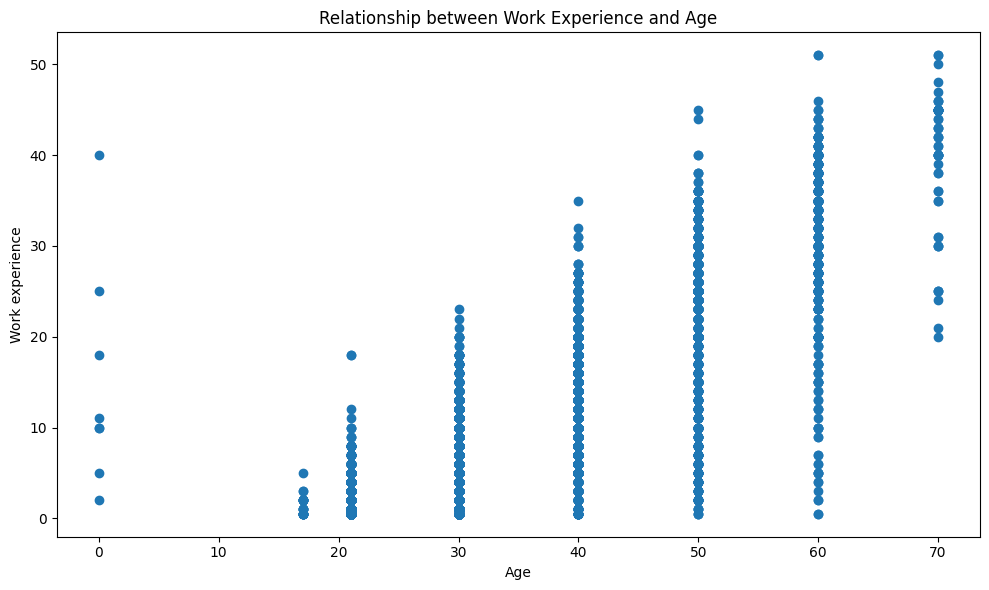

In [16]:
## Write your code here
import numpy as np


# Convert YearsCodePro to numeric
def convert_years_code_pro(value):
    if value == 'Less than 1 year':
        return 0.5
    elif value == 'More than 50 years':
        return 51
    try:
        return float(value)
    except (ValueError, TypeError):
        return np.nan

df['YearsCodeProNumeric'] = df['YearsCodePro'].apply(convert_years_code_pro)

# Drop rows with NaN values
df_clean = df.dropna(subset=['YearsCodeProNumeric', 'AgeNumeric'])

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(x='AgeNumeric', y='YearsCodeProNumeric', data=df_clean)
plt.title('Relationship between Work Experience and Age')
plt.xlabel('Age')
plt.ylabel('Work experience')
plt.tight_layout()
plt.show()


### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


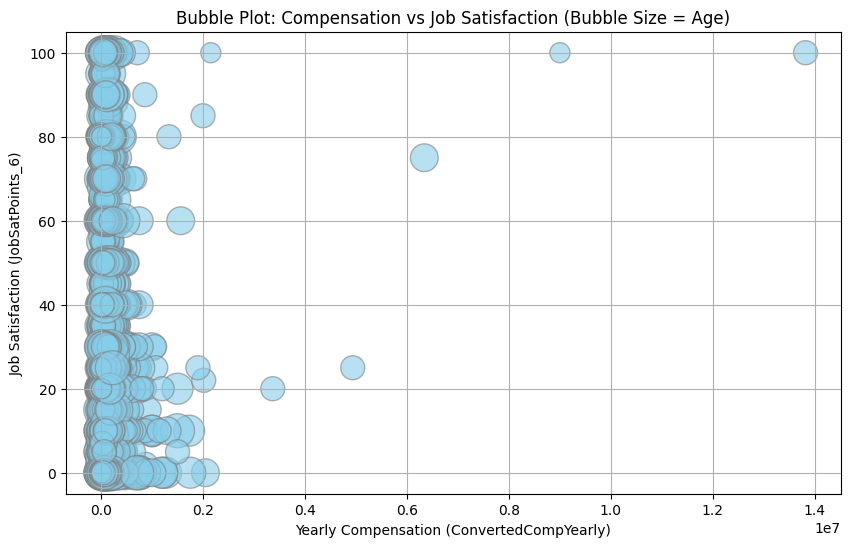

In [23]:
# Drop rows with NaN values
df_clean = df.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6', 'AgeNumeric'])

# Create bubble plot
plt.figure(figsize=(10, 6))
plt.scatter(
    df['ConvertedCompYearly'],
    df['JobSatPoints_6'],
    s=df['AgeNumeric'] * 10,  # Bubble size scaled by age
    alpha=0.6,
    color='skyblue',
    edgecolors='grey',
    linewidth=1
)
plt.title('Bubble Plot: Compensation vs Job Satisfaction (Bubble Size = Age)')
plt.xlabel('Yearly Compensation (ConvertedCompYearly)')
plt.ylabel('Job Satisfaction (JobSatPoints_6)')
plt.grid(True)
plt.show()


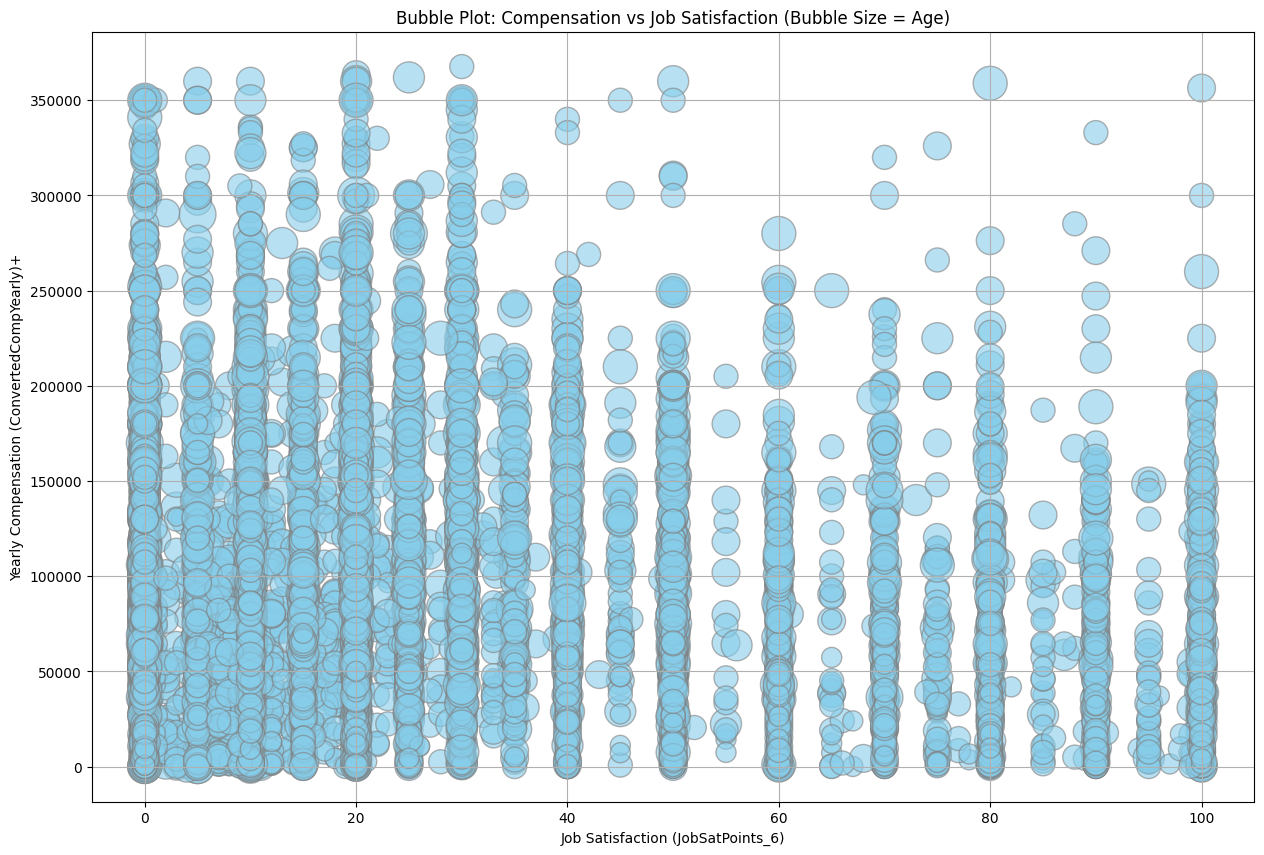

In [25]:
## Write your code here

# Drop rows with NaN values
df_clean = df.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6', 'AgeNumeric'])

# Filter out extreme outliers (e.g., above 90th percentile)
upper_limit = df_clean['ConvertedCompYearly'].quantile(0.99)
df_filtered = df_clean[df_clean['ConvertedCompYearly'] <= upper_limit]


# Create bubble plot
plt.figure(figsize=(15, 10))
plt.scatter(
    df_filtered['JobSatPoints_6'],
    df_filtered['ConvertedCompYearly'],
    s=df_filtered['AgeNumeric'] * 10,  # Bubble size scaled by age
    alpha=0.6,
    color='skyblue',
    edgecolors='grey',
    linewidth=1
)
plt.title('Bubble Plot: Compensation vs Job Satisfaction (Bubble Size = Age)')
plt.xlabel('Job Satisfaction (JobSatPoints_6)')
plt.ylabel('Yearly Compensation (ConvertedCompYearly)+')
plt.grid(True)
plt.show()


#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


In [26]:
df['LanguageHaveWorkedWith'].unique()

array(['Assembly;Bash/Shell (all shells);C;C++;HTML/CSS;Java;JavaScript;Python;R;SQL;TypeScript',
       'JavaScript;Julia;Python;SQL;TypeScript',
       'HTML/CSS;JavaScript;Python;SQL;TypeScript', ...,
       'Bash/Shell (all shells);C;HTML/CSS;Java;JavaScript;PHP;SQL',
       'C#;HTML/CSS;Java;JavaScript;PHP;Python',
       'Assembly;C;C++;Java;Objective-C;PHP;SQL'],
      shape=(7843,), dtype=object)

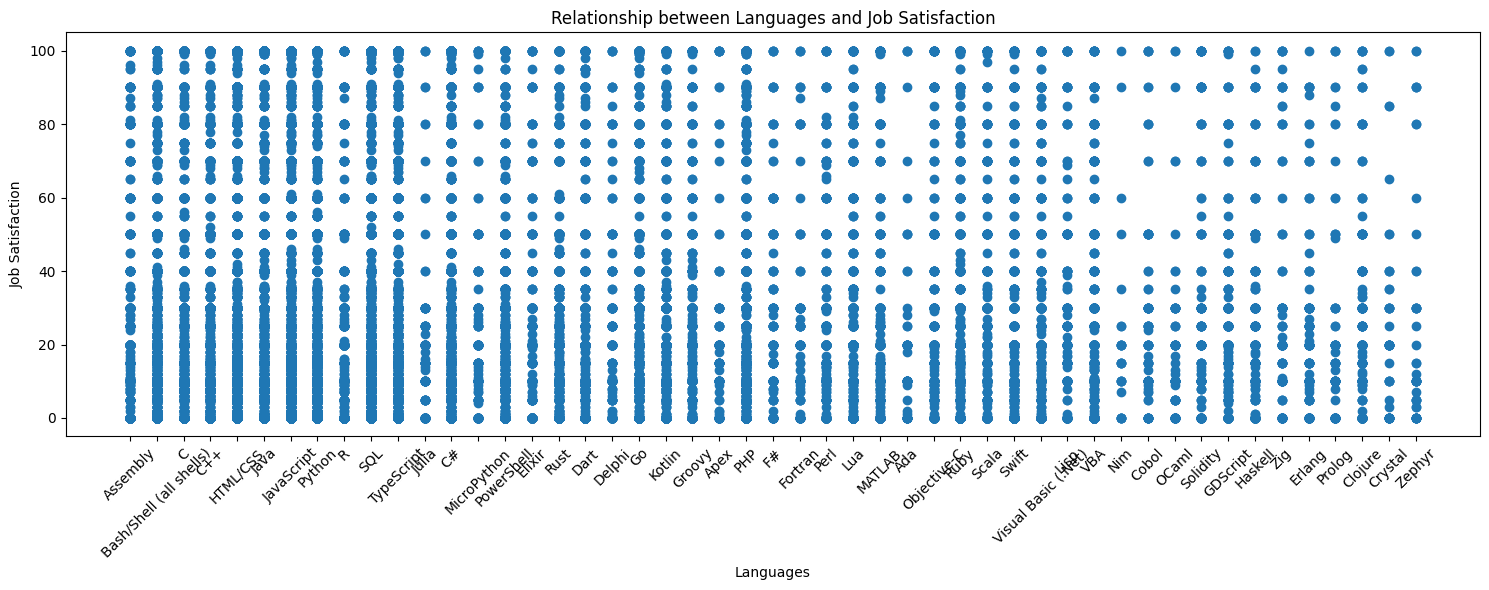

In [32]:
## Write your code here
# Split multiple entries (assuming comma-separated values)

df['Languages'] = df['LanguageHaveWorkedWith'].str.split(';')

# Flatten the list of databases
all_languages = df.explode('Languages')
all_languages['Languages'] = all_languages['Languages'].str.strip()

# Drop rows with NaN values
All_clean = all_languages.dropna(subset=['Languages', 'JobSatPoints_6'])


# Plot
plt.figure(figsize=(15, 6))
plt.scatter(x='Languages', y='JobSatPoints_6', data=All_clean)
plt.title('Relationship between Languages and Job Satisfaction')
plt.xlabel('Languages')
plt.ylabel('Job Satisfaction')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


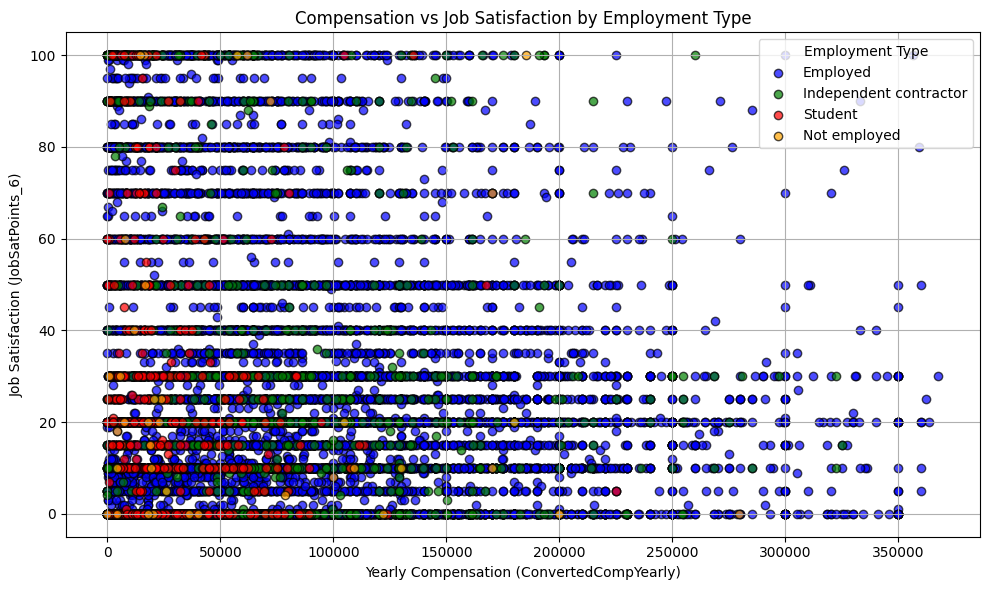

In [37]:
## Write your code 

# Drop rows with NaN values
df = df.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6', 'Employment'])

# Map to keep only the first item
df['EmploymentMapped'] = df['Employment'].apply(lambda x: x.split(',')[0] if pd.notnull(x) else x)

# Define unique employment types and assign colors
employment_types = df['EmploymentMapped'].unique()
colors = ['blue', 'green', 'red', 'orange']
color_map = dict(zip(employment_types, colors))

# Filter out extreme outliers (e.g., above 90th percentile)
upper_limit = df['ConvertedCompYearly'].quantile(0.99)
df_filtered = df[df['ConvertedCompYearly'] <= upper_limit]


# Plot
plt.figure(figsize=(10, 6))
for emp_type in employment_types:
    subset = df_filtered[df_filtered['EmploymentMapped'] == emp_type]
    plt.scatter(
        subset['JobSatPoints_6'],
        subset['ConvertedCompYearly'],
        label=emp_type,
        color=color_map[emp_type],
        alpha=0.7,
        edgecolors='black'
    )

plt.title('Compensation vs Job Satisfaction by Employment Type')
plt.xlabel('Job Satisfaction (JobSatPoints_6)')
plt.ylabel('Yearly Compensation (ConvertedCompYearly)')
plt.legend(title='Employment Type')
plt.grid(True)
plt.tight_layout()
plt.show()


#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


In [38]:
df['AgeNumeric'].unique()

array([21, 40, 30, 50, 60, 70, 17,  0])

/tmp/ipykernel_300/2565487095.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AgeGroup'] = df['AgeNumeric'].apply(age_group)


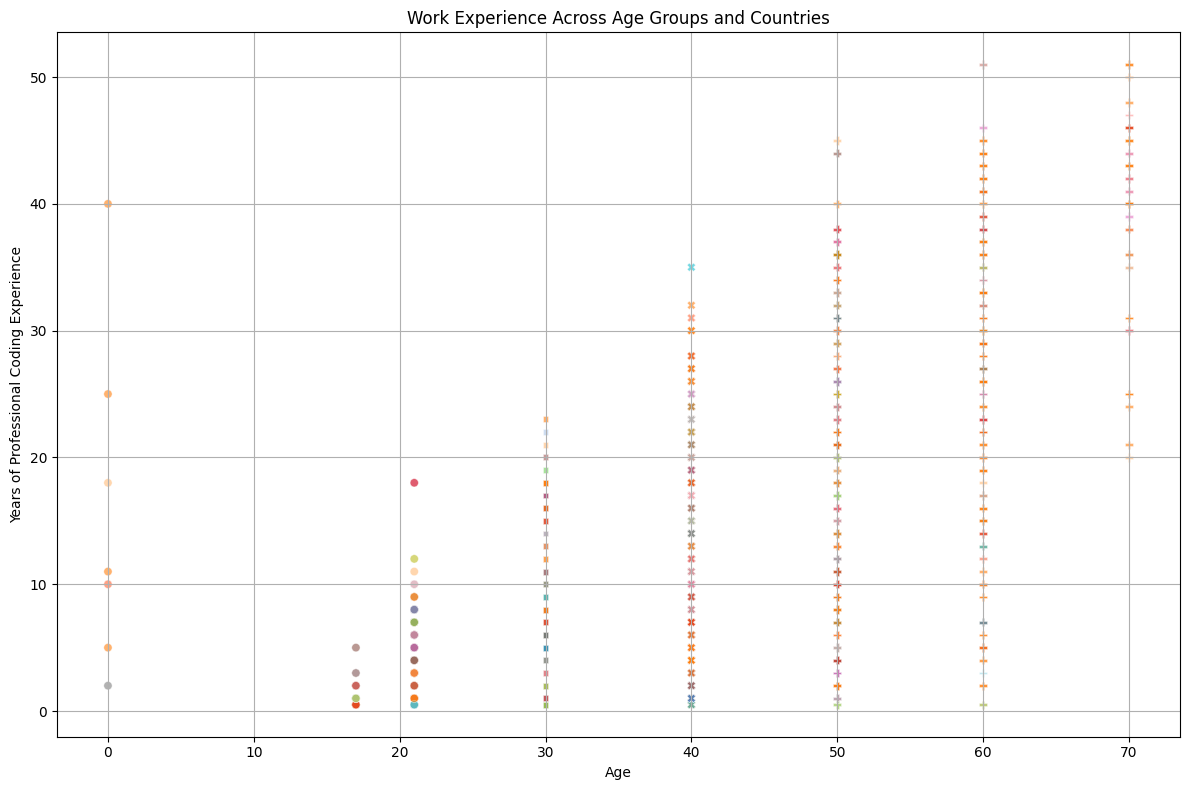

In [39]:
## Write your code here

df= df.dropna(subset=['AgeNumeric', 'Country', 'YearsCodeProNumeric'])

#Define age groups
def age_group(age):
    if age < 25:
        return '<25'
    elif age < 35:
        return '25-34'
    elif age < 45:
        return '35-44'
    else:
        return '45+'

df['AgeGroup'] = df['AgeNumeric'].apply(age_group)

# Use seaborn to plot with color palette
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x='AgeNumeric',
    y='YearsCodeProNumeric',
    hue='Country',
    style='AgeGroup',
    palette='tab20',  # Limited palette for readability
    alpha=0.6,
    legend=False  # Hide legend due to large number of countries
)

plt.title('Work Experience Across Age Groups and Countries')
plt.xlabel('Age')
plt.ylabel('Years of Professional Coding Experience')
plt.grid(True)
plt.tight_layout()
plt.show()


### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
